In [1]:
!pip install openseespy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import openseespy.opensees as ops

In [3]:
m = 1.0
k = 100.0
zeta = 0.05

omega_n = np.sqrt(k / m)
c = 2 * zeta * m * omega_n

F0 = 10.0
omega = 0.8 * omega_n

t_max = 10.0
dt = 0.01

time = np.arange(0, t_max + dt, dt)

In [4]:
ops.wipe()

ops.model("basic", "-ndm", 1, "-ndf", 1)

ops.node(1, 0.0)
ops.node(2, 0.0)

ops.fix(1, 1)

ops.mass(2, m)

ops.uniaxialMaterial("Elastic", 1, k)
ops.element("zeroLength", 1, 1, 2, "-mat", 1, "-dir", 1)

ops.rayleigh(0.0, 0.0, 0.0, c / k)

ops.timeSeries("Trig", 1, 0.0, t_max, 1.0 / (2 * np.pi / omega), "-factor", F0)
ops.pattern("Plain", 1, 1)
ops.load(2, 1.0)

ops.constraints("Plain")
ops.numberer("Plain")
ops.system("BandGeneral")
ops.test("NormDispIncr", 1.0e-10, 10)
ops.algorithm("Newton")
ops.integrator("Newmark", 0.5, 0.25)
ops.analysis("Transient")

In [5]:
u_fem = []
v_fem = []
a_fem = []
t_fem = []

for t in time:
    ok = ops.analyze(1, dt)

    if ok != 0:
        print("Error en el análisis en t =", t)
        break

    t_fem.append(ops.getTime())
    u_fem.append(ops.nodeDisp(2, 1))
    v_fem.append(ops.nodeVel(2, 1))
    a_fem.append(ops.nodeAccel(2, 1))

t_fem = np.array(t_fem)
u_fem = np.array(u_fem)
v_fem = np.array(v_fem)
a_fem = np.array(a_fem)

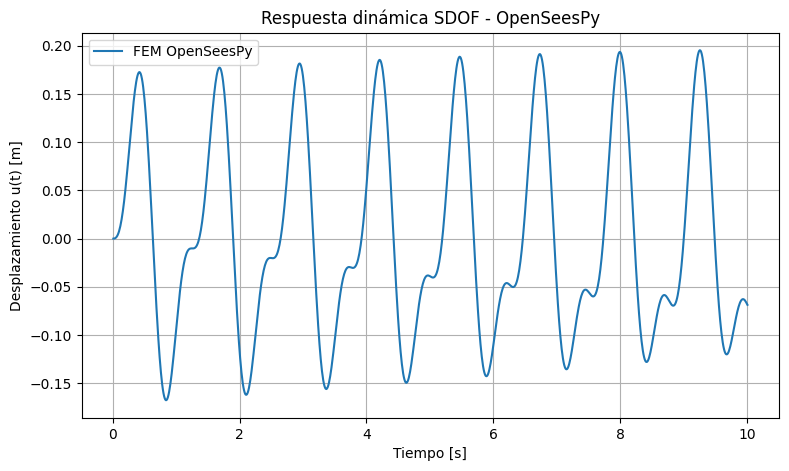

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(t_fem, u_fem, label="FEM OpenSeesPy")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento u(t) [m]")
plt.title("Respuesta dinámica SDOF - OpenSeesPy")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, t):
        return self.net(t)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

t_col = torch.linspace(0, t_max, 1000).view(-1, 1).to(device)
t_col.requires_grad_(True)

t0 = torch.tensor([[0.0]], device=device, requires_grad=True)

model = PINN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

$R(t) = m\ddot{u}_{\theta}(t) + c\dot{u}_{\theta}(t) + ku_{\theta}(t) - F_0 \sin(\omega t)$

$\mathbf{L} = \mathbf{L}_{physics} + \mathbf{L}_{IC} + \mathbf{L}_{data}$

In [9]:
def pinn_loss(model, t_col, t0):
    u = model(t_col)

    du_dt = torch.autograd.grad(
        u,
        t_col,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2u_dt2 = torch.autograd.grad(
        du_dt,
        t_col,
        grad_outputs=torch.ones_like(du_dt),
        create_graph=True
    )[0]

    force = F0 * torch.sin(omega * t_col)

    residual = m * d2u_dt2 + c * du_dt + k * u - force

    loss_physics = torch.mean(residual**2)

    u0 = model(t0)

    du0_dt = torch.autograd.grad(
        u0,
        t0,
        grad_outputs=torch.ones_like(u0),
        create_graph=True
    )[0]

    loss_ic = torch.mean(u0**2) + torch.mean(du0_dt**2)

    return loss_physics, loss_ic

In [10]:
epochs = 8000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_physics, loss_ic = pinn_loss(model, t_col, t0)

    loss = loss_physics + 100 * loss_ic

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(
            "Epoch:",
            epoch,
            "Loss:",
            loss.item(),
            "Physics:",
            loss_physics.item(),
            "IC:",
            loss_ic.item()
        )

Epoch: 0 Loss: 862.97509765625 Physics: 858.1810302734375 IC: 0.04794042557477951
Epoch: 500 Loss: 49.62686538696289 Physics: 49.5234489440918 IC: 0.0010341661982238293
Epoch: 1000 Loss: 49.59855270385742 Physics: 49.501617431640625 IC: 0.0009693357860669494
Epoch: 1500 Loss: 49.55248260498047 Physics: 49.4536018371582 IC: 0.0009888261556625366
Epoch: 2000 Loss: 49.44749450683594 Physics: 49.33006286621094 IC: 0.0011743141803890467
Epoch: 2500 Loss: 49.18293762207031 Physics: 48.956764221191406 IC: 0.002261749003082514
Epoch: 3000 Loss: 49.017818450927734 Physics: 48.634124755859375 IC: 0.003836924210190773
Epoch: 3500 Loss: 48.96041488647461 Physics: 48.54758071899414 IC: 0.004128344357013702
Epoch: 4000 Loss: 48.87094497680664 Physics: 48.485347747802734 IC: 0.003855970688164234
Epoch: 4500 Loss: 48.693233489990234 Physics: 48.38656997680664 IC: 0.0030666461680084467
Epoch: 5000 Loss: 48.50526428222656 Physics: 48.244754791259766 IC: 0.0026050894521176815
Epoch: 5500 Loss: 48.6618347

In [11]:
t_eval = torch.tensor(t_fem.reshape(-1, 1), dtype=torch.float32).to(device)

with torch.no_grad():
    u_pinn = model(t_eval).cpu().numpy().flatten()

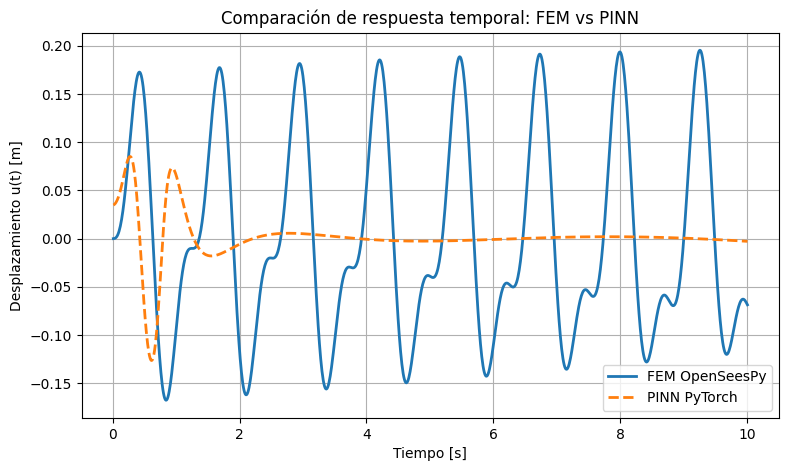

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(t_fem, u_fem, label="FEM OpenSeesPy", linewidth=2)
plt.plot(t_fem, u_pinn, "--", label="PINN PyTorch", linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento u(t) [m]")
plt.title("Comparación de respuesta temporal: FEM vs PINN")
plt.grid(True)
plt.legend()
plt.show()

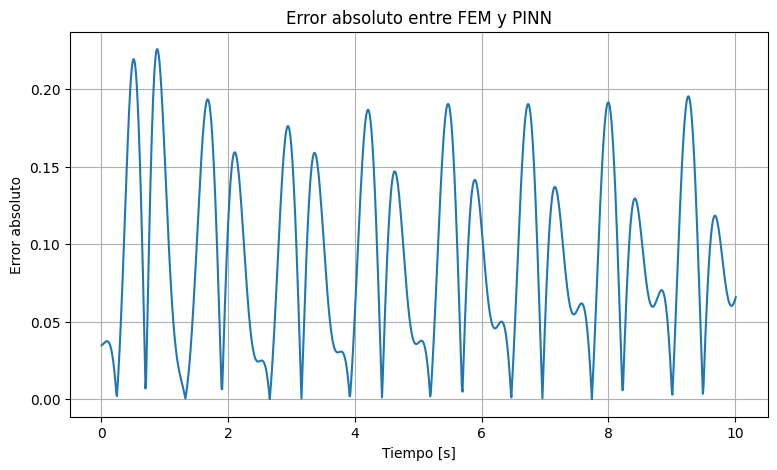

In [13]:
error_abs = np.abs(u_fem - u_pinn)

plt.figure(figsize=(9, 5))
plt.plot(t_fem, error_abs)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error absoluto")
plt.title("Error absoluto entre FEM y PINN")
plt.grid(True)
plt.show()

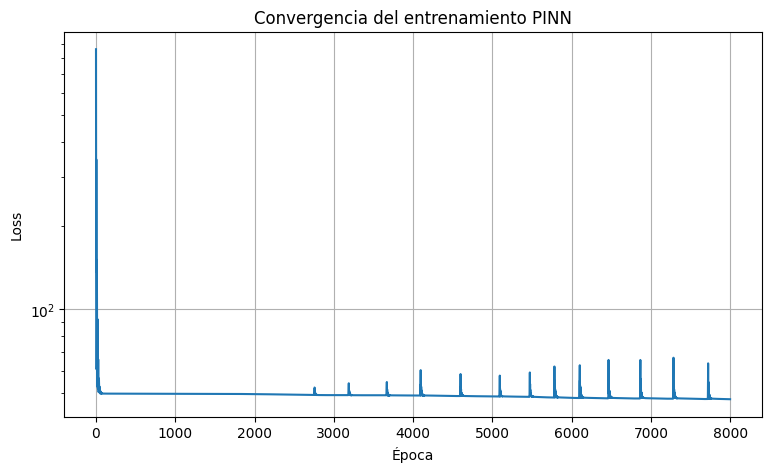

In [14]:
plt.figure(figsize=(9, 5))
plt.semilogy(loss_history)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Convergencia del entrenamiento PINN")
plt.grid(True)
plt.show()

In [15]:
error_l2 = np.linalg.norm(u_fem - u_pinn) / np.linalg.norm(u_fem)

print("Error relativo L2:", error_l2)

Error relativo L2: 1.0399537050821848
